# 03 - Earnings Call Transcript NLP Analysis
## CAVA Group Investment Analysis

**Objective:** Analyze CAVA's earnings call transcripts to:
1. Track management tone changes over time using VADER and FinBERT
2. Monitor keyword frequency for key investment themes
3. Validate modeling conclusions with qualitative evidence
4. Identify leading language signals that precede SSSG changes

**Data:** 11 earnings call transcripts (Q2 2023 – Q4 2025) from Capital IQ

**Approach:**
- Extract text from PDFs using pdfplumber
- Separate prepared remarks from Q&A section
- Apply VADER and FinBERT sentiment scoring
- Track keyword frequency across investment theme categories
- Compare VADER vs FinBERT to understand where financial context matters

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pdfplumber
import torch
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'axes.grid': False,
    'legend.fontsize': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'
TRANSCRIPT_DIR = f'{BASE_DIR}/data/earnings_transcripts'
analyzer = SentimentIntensityAnalyzer()

print('Libraries loaded.')

Libraries loaded.


---
## Part 1: Load & Extract Transcripts

In [2]:
# ── Transcript filename to quarter mapping ─────────────────────────────────────
transcript_map = {
    'CAVA Group Inc._Earnings Call_2023-08-15_English.pdf': 'Q2 2023',
    'CAVA Group Inc._Earnings Call_2023-11-07_English.pdf': 'Q3 2023',
    'CAVA Group Inc._Earnings Call_2024-02-27_English.pdf': 'Q4 2023',
    'CAVA Group Inc._Earnings Call_2024-05-28_English.pdf': 'Q1 2024',
    'CAVA Group Inc._Earnings Call_2024-08-22_English.pdf': 'Q2 2024',
    'CAVA Group Inc._Earnings Call_2024-11-12_English.pdf': 'Q3 2024',
    'CAVA Group Inc._Earnings Call_2025-02-25_English.pdf': 'Q4 2024',
    'CAVA Group Inc._Earnings Call_2025-05-15_English.pdf': 'Q1 2025',
    'CAVA Group Inc._Earnings Call_2025-08-12_English.pdf': 'Q2 2025',
    'CAVA Group Inc._Earnings Call_2025-11-04_English.pdf': 'Q3 2025',
    'CAVA Group Inc._Earnings Call_2026-02-24_English.pdf': 'Q4 2025',
}

# ── Extract text from PDFs ─────────────────────────────────────────────────────
def extract_transcript_text(pdf_path):
    """Extract full text from earnings call PDF using pdfplumber"""
    text = ''
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + '\n'
    except Exception as e:
        print(f'Error extracting {pdf_path}: {e}')
    return text

def split_prepared_qa(text):
    """
    Split Capital IQ transcript into prepared remarks and Q&A.
    
    Capital IQ structure:
    [Header/estimates table]
    [Call Participants]
    'Presentation'  <- actual content starts here
        [Prepared remarks]
    'Question and Answer'  <- Q&A starts here
        [Q&A content]
    """
    # Find start of actual content (skip header)
    presentation_markers = ['Presentation\n', 'PRESENTATION\n']
    qa_markers = [
        'Question and Answer\n',
        'Question And Answer\n',
        'QUESTION AND ANSWER\n',
        'Questions and Answers\n',
        'Question & Answer\n',
    ]

    # Find presentation start
    presentation_start = 0
    for marker in presentation_markers:
        idx = text.find(marker)
        if idx != -1:
            presentation_start = idx + len(marker)
            break

    # Find Q&A start
    qa_start = None
    for marker in qa_markers:
        idx = text.find(marker)
        if idx != -1:
            qa_start = idx
            break

    # Fallback: look for operator introducing Q&A
    if qa_start is None:
        qa_fallback = [
            'open it up for Q&A',
            'open the call for Q&A',
            'begin the Q&A',
            'start the Q&A',
            'open for questions',
        ]
        for marker in qa_fallback:
            idx = text.lower().find(marker.lower())
            if idx != -1:
                next_break = text.find('\n', idx + len(marker))
                if next_break != -1:
                    qa_start = next_break
                break

    if qa_start is not None:
        prepared = text[presentation_start:qa_start]
        qa = text[qa_start:]
    else:
        prepared = text[presentation_start:]
        qa = ''

    return prepared, qa

# ── Load all transcripts ───────────────────────────────────────────────────────
transcripts = {}
for filename, quarter in transcript_map.items():
    filepath = os.path.join(TRANSCRIPT_DIR, filename)
    if os.path.exists(filepath):
        full_text = extract_transcript_text(filepath)
        prepared, qa = split_prepared_qa(full_text)
        transcripts[quarter] = {
            'full_text': full_text,
            'prepared': prepared,
            'qa': qa,
            'word_count': len(full_text.split()),
            'prepared_word_count': len(prepared.split()),
            'qa_word_count': len(qa.split()),
            'has_qa': len(qa) > 100
        }
        print(f'{quarter}: total={len(full_text.split()):,}w  '
              f'prepared={len(prepared.split()):,}w  '
              f'qa={len(qa.split()):,}w  '
              f'Q&A split: {"✅" if len(qa) > 100 else "❌"}')
    else:
        print(f'{quarter}: FILE NOT FOUND — {filename}')

print(f'\nLoaded {len(transcripts)} transcripts')

# Sanity check: prepared should have substantial content
print('\nSanity check (prepared remarks should be 1000+ words):')
for q, data in transcripts.items():
    status = '✅' if data['prepared_word_count'] > 500 else '⚠️ TOO SHORT'
    print(f'  {q}: {data["prepared_word_count"]:,} words {status}')

Q2 2023: total=6,912w  prepared=3,166w  qa=3,492w  Q&A split: ✅
Q3 2023: total=8,172w  prepared=2,872w  qa=5,031w  Q&A split: ✅
Q4 2023: total=8,314w  prepared=3,234w  qa=4,789w  Q&A split: ✅
Q1 2024: total=8,974w  prepared=3,349w  qa=5,332w  Q&A split: ✅
Q2 2024: total=10,369w  prepared=3,785w  qa=6,282w  Q&A split: ✅
Q3 2024: total=6,886w  prepared=2,939w  qa=3,660w  Q&A split: ✅
Q4 2024: total=9,517w  prepared=3,560w  qa=5,642w  Q&A split: ✅
Q1 2025: total=7,803w  prepared=3,161w  qa=4,372w  Q&A split: ✅
Q2 2025: total=10,446w  prepared=3,685w  qa=6,423w  Q&A split: ✅
Q3 2025: total=10,641w  prepared=3,284w  qa=7,004w  Q&A split: ✅
Q4 2025: total=10,611w  prepared=3,377w  qa=6,864w  Q&A split: ✅

Loaded 11 transcripts

Sanity check (prepared remarks should be 1000+ words):
  Q2 2023: 3,166 words ✅
  Q3 2023: 2,872 words ✅
  Q4 2023: 3,234 words ✅
  Q1 2024: 3,349 words ✅
  Q2 2024: 3,785 words ✅
  Q3 2024: 2,939 words ✅
  Q4 2024: 3,560 words ✅
  Q1 2025: 3,161 words ✅
  Q2 2025: 3,

---
## Part 2: Sentiment Analysis — VADER vs FinBERT

We apply two complementary sentiment models at three levels:
1. **Full transcript** — overall tone
2. **Prepared remarks only** — management's scripted tone  
3. **Q&A only** — management's unscripted, spontaneous tone (often more revealing)

### Why Two Models?

**VADER** (Valence Aware Dictionary and sEntiment Reasoner)
- Rule-based, uses a predefined sentiment lexicon
- Fast, no training required
- Weakness: struggles with financial jargon and implicit negative language
  e.g. "navigating a fog" scores near-neutral in VADER but is clearly bearish

**FinBERT** (Financial BERT)
- Deep learning model fine-tuned on financial text (earnings calls, analyst 
  reports, financial news)
- Understands context and domain-specific language
- e.g. "miss", "headwind", "cautious outlook" are correctly scored as negative
- Weakness: slower, 512-token limit requires chunking long transcripts

**Our approach:** Use FinBERT as the primary scorer for financial 
interpretation, VADER as a baseline cross-check. When both models agree 
on direction, conviction is higher. Divergences reveal cases where 
financial context matters — exactly where FinBERT adds value over VADER.

In [3]:
# ── Load FinBERT ───────────────────────────────────────────────────────────────
print('Loading FinBERT...')
finbert = pipeline(
    'sentiment-analysis',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    device=0 if torch.cuda.is_available() else -1
)
print(f'FinBERT loaded. Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

Loading FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded. Device: CPU


In [4]:
# ── Scoring functions ──────────────────────────────────────────────────────────
def score_text_vader(text):
    """Score long text with VADER by averaging sentence-level scores"""
    if not text or len(text.strip()) < 10:
        return {'compound': 0, 'pos': 0, 'neg': 0, 'neu': 1}

    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

    if not sentences:
        return {'compound': 0, 'pos': 0, 'neg': 0, 'neu': 1}

    scores = [analyzer.polarity_scores(s) for s in sentences]
    return {
        'compound': np.mean([s['compound'] for s in scores]),
        'pos': np.mean([s['pos'] for s in scores]),
        'neg': np.mean([s['neg'] for s in scores]),
        'neu': np.mean([s['neu'] for s in scores])
    }

def score_text_finbert(text, max_chunk_words=400):
    """
    Score text using FinBERT.
    Chunks text into segments within FinBERT's 512-token limit.
    Returns compound score: positive=+confidence, negative=-confidence
    """
    if not text or len(text.strip()) < 10:
        return {'compound': 0, 'label': 'neutral', 'confidence': 0}

    # Split into sentences
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]

    if not sentences:
        return {'compound': 0, 'label': 'neutral', 'confidence': 0}

    # Chunk sentences to stay within token limit
    chunks = []
    current_chunk = []
    current_words = 0

    for sent in sentences:
        words = len(sent.split())
        if current_words + words > max_chunk_words and current_chunk:
            chunks.append(' '.join(current_chunk))
            current_chunk = [sent]
            current_words = words
        else:
            current_chunk.append(sent)
            current_words += words

    if current_chunk:
        chunks.append(' '.join(current_chunk))

    # Score each chunk
    scores = []
    for chunk in chunks:
        try:
            # Truncate to 512 tokens as safety measure
            result = finbert(chunk[:1500], truncation=True, max_length=512)[0]
            label = result['label'].lower()
            confidence = result['score']
            if label == 'positive':
                compound = confidence
            elif label == 'negative':
                compound = -confidence
            else:
                compound = 0
            scores.append(compound)
        except Exception as e:
            scores.append(0)

    avg_compound = np.mean(scores) if scores else 0
    return {
        'compound': avg_compound,
        'label': 'positive' if avg_compound > 0.05 else
                 'negative' if avg_compound < -0.05 else 'neutral',
        'n_chunks': len(chunks)
    }

print('Scoring functions defined.')

Scoring functions defined.


In [5]:
# ── Quick test before scoring all transcripts ──────────────────────────────────
test_quarter = 'Q2 2023'
test_prepared = transcripts[test_quarter]['prepared']

print(f'Test on {test_quarter} prepared remarks:')
print(f'  Word count: {len(test_prepared.split())}')
print(f'  First 200 chars: {test_prepared[:200]}')

vader_test = score_text_vader(test_prepared)
finbert_test = score_text_finbert(test_prepared)

print(f'\n  VADER compound:   {vader_test["compound"]:.3f}')
print(f'  FinBERT compound: {finbert_test["compound"]:.3f}')
print(f'  FinBERT chunks:   {finbert_test["n_chunks"]}')

Test on Q2 2023 prepared remarks:
  Word count: 3166
  First 200 chars: Operator
Good afternoon, ladies and gentlemen, and welcome to the CAVA Second Quarter 2023 Earnings Conference Call. [Operator
Instructions] This call is being recorded on Tuesday, the 15th of August 

  VADER compound:   0.361
  FinBERT compound: 0.434
  FinBERT chunks:   9


In [7]:
# ── Quick test before scoring all transcripts ──────────────────────────────────
test_quarter = 'Q2 2023'
test_prepared = transcripts[test_quarter]['prepared']
test_qa = transcripts[test_quarter]['qa']

print(f'Test on {test_quarter}:')
print(f'\n--- PREPARED REMARKS ---')
print(f'Word count: {len(test_prepared.split())}')
print(f'First 300 chars:')
print(test_prepared[:300])
print(f'\nLast 200 chars:')
print(test_prepared[-200:])

print(f'\n--- Q&A SECTION ---')
print(f'Word count: {len(test_qa.split())}')
print(f'First 300 chars:')
print(test_qa[:300])
print(f'\nLast 200 chars:')
print(test_qa[-200:])

Test on Q2 2023:

--- PREPARED REMARKS ---
Word count: 3166
First 300 chars:
Operator
Good afternoon, ladies and gentlemen, and welcome to the CAVA Second Quarter 2023 Earnings Conference Call. [Operator
Instructions] This call is being recorded on Tuesday, the 15th of August 2023.
I would now like to turn the conference over to Matt Milanovich. Please go ahead.
Matt Milanov

Last 200 chars:
 up for Q&A.
Copyright © 2023 S&P Global Market Intelligence, a division of S&P Global Inc. All Rights reserved.
spglobal.com/marketintelligence 7
CAVA GROUP, INC. FQ2 2023 EARNINGS CALL AUG 15, 2023


--- Q&A SECTION ---
Word count: 3492
First 300 chars:
Question and Answer
Operator
[Operator Instructions] Your first question comes from the line of John Ivankoe from JPMorgan.
John William Ivankoe
JPMorgan Chase & Co, Research Division
I remember when we spoke about the first quarter, and first quarter obviously had exceptional comps, I mean, by any 

Last 200 chars:
dpoors.com/usratingsfees.
© 202

In [8]:
# ── Score all transcripts with both models ─────────────────────────────────────
print('Scoring all transcripts with VADER and FinBERT...')
print('(FinBERT on CPU may take 10-20 minutes)\n')

sentiment_results = []
for quarter, data in transcripts.items():
    print(f'Processing {quarter}...', end=' ')

    # VADER
    vader_full = score_text_vader(data['full_text'])
    vader_prepared = score_text_vader(data['prepared'])
    vader_qa = score_text_vader(data['qa'])

    # FinBERT
    finbert_prepared = score_text_finbert(data['prepared'])
    finbert_qa = score_text_finbert(data['qa'])

    sentiment_results.append({
        'quarter': quarter,
        # VADER
        'vader_full': round(vader_full['compound'], 3),
        'vader_prepared': round(vader_prepared['compound'], 3),
        'vader_qa': round(vader_qa['compound'], 3),
        'vader_pos': round(vader_full['pos'], 3),
        'vader_neg': round(vader_full['neg'], 3),
        # FinBERT
        'finbert_prepared': round(finbert_prepared['compound'], 3),
        'finbert_qa': round(finbert_qa['compound'], 3),
        'finbert_prepared_label': finbert_prepared['label'],
        'finbert_qa_label': finbert_qa['label'],
        # Meta
        'word_count': data['word_count'],
        'prepared_word_count': data['prepared_word_count'],
        'has_qa': data['has_qa']
    })
    print(f'VADER={vader_prepared["compound"]:.3f}  '
          f'FinBERT={finbert_prepared["compound"]:.3f} '
          f'({finbert_prepared["label"]})')

sentiment_df = pd.DataFrame(sentiment_results)

# Sort by quarter order
quarter_order = list(transcript_map.values())
sentiment_df['quarter_idx'] = sentiment_df['quarter'].map(
    {q: i for i, q in enumerate(quarter_order)}
)
sentiment_df = sentiment_df.sort_values('quarter_idx').reset_index(drop=True)

print('\n=== SENTIMENT COMPARISON: VADER vs FinBERT (Prepared Remarks) ===')
print(sentiment_df[['quarter', 'vader_prepared', 'finbert_prepared',
                     'finbert_prepared_label',
                     'vader_qa', 'finbert_qa']].to_string(index=False))

Scoring all transcripts with VADER and FinBERT...
(FinBERT on CPU may take 10-20 minutes)

Processing Q2 2023... VADER=0.361  FinBERT=0.434 (positive)
Processing Q3 2023... VADER=0.358  FinBERT=0.481 (positive)
Processing Q4 2023... VADER=0.368  FinBERT=0.422 (positive)
Processing Q1 2024... VADER=0.337  FinBERT=0.567 (positive)
Processing Q2 2024... VADER=0.327  FinBERT=0.497 (positive)
Processing Q3 2024... VADER=0.344  FinBERT=0.720 (positive)
Processing Q4 2024... VADER=0.378  FinBERT=0.610 (positive)
Processing Q1 2025... VADER=0.360  FinBERT=0.538 (positive)
Processing Q2 2025... VADER=0.393  FinBERT=0.716 (positive)
Processing Q3 2025... VADER=0.340  FinBERT=0.679 (positive)
Processing Q4 2025... VADER=0.364  FinBERT=0.550 (positive)

=== SENTIMENT COMPARISON: VADER vs FinBERT (Prepared Remarks) ===
quarter  vader_prepared  finbert_prepared finbert_prepared_label  vader_qa  finbert_qa
Q2 2023           0.361             0.434               positive     0.239       0.094
Q3 2023 

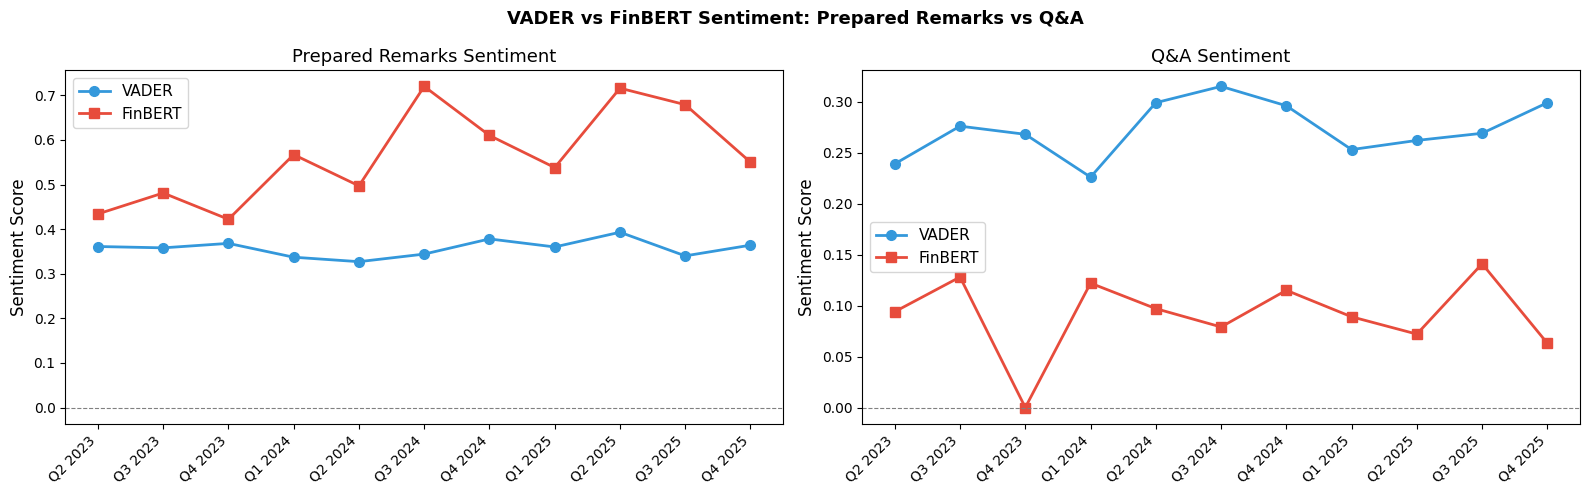

Saved: outputs/figures/vader_vs_finbert.png


In [9]:
# ── VADER vs FinBERT comparison plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('VADER vs FinBERT Sentiment: Prepared Remarks vs Q&A',
             fontweight='bold', fontsize=13)

x = range(len(sentiment_df))
quarters = sentiment_df['quarter'].tolist()

# Prepared remarks
ax = axes[0]
ax.plot(x, sentiment_df['vader_prepared'], marker='o', color='#3498db',
        linewidth=2, label='VADER', markersize=7)
ax.plot(x, sentiment_df['finbert_prepared'], marker='s', color='#e74c3c',
        linewidth=2, label='FinBERT', markersize=7)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha='right')
ax.set_title('Prepared Remarks Sentiment')
ax.set_ylabel('Sentiment Score')
ax.legend()

# Q&A
ax = axes[1]
ax.plot(x, sentiment_df['vader_qa'], marker='o', color='#3498db',
        linewidth=2, label='VADER', markersize=7)
ax.plot(x, sentiment_df['finbert_qa'], marker='s', color='#e74c3c',
        linewidth=2, label='FinBERT', markersize=7)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha='right')
ax.set_title('Q&A Sentiment')
ax.set_ylabel('Sentiment Score')
ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/vader_vs_finbert.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/vader_vs_finbert.png')

---
## Part 3: Keyword Frequency Analysis

We track five keyword categories that capture key investment themes:
- **Growth signals** — bullish language about demand and momentum
- **Caution signals** — risk language about macro headwinds and competition
- **SSSG-specific** — references to comparable store performance
- **Digital** — references to digital ordering and technology
- **Value/Pricing** — references to pricing power and consumer value perception

Frequencies are normalized per 1,000 words to allow fair comparison across
transcripts of different lengths.

In [10]:
# ── Keyword categories ─────────────────────────────────────────────────────────
keyword_categories = {
    'growth_signals': [
        'traffic', 'momentum', 'strong', 'exceed', 'accelerat',
        'outperform', 'robust', 'healthy', 'positive', 'record',
        'increase', 'expand', 'best', 'outstanding', 'impressive'
    ],
    'caution_signals': [
        'uncertain', 'pressure', 'challeng', 'macro', 'cautious',
        'headwind', 'soften', 'decelerat', 'slow', 'difficult',
        'concern', 'risk', 'fog', 'navigate', 'volatile', 'weaken'
    ],
    'sssg_specific': [
        'same-restaurant', 'same restaurant', 'comparable',
        'comp sales', 'comps', 'same-store'
    ],
    'digital': [
        'digital', 'online', 'app', 'delivery', 'mobile',
        'technology', 'platform'
    ],
    'value_pricing': [
        'value', 'price', 'affordable', 'premium', 'ticket',
        'average check', 'menu price', 'inflation'
    ]
}

def count_keywords(text, keywords):
    """Count keyword occurrences per 1000 words (normalized)"""
    if not text:
        return 0
    text_lower = text.lower()
    word_count = len(text.split())
    if word_count == 0:
        return 0
    count = sum(text_lower.count(kw.lower()) for kw in keywords)
    return round((count / word_count) * 1000, 2)

# ── Count keywords for each transcript ────────────────────────────────────────
keyword_results = []
for quarter, data in transcripts.items():
    row = {'quarter': quarter}
    for category, keywords in keyword_categories.items():
        row[f'{category}_full'] = count_keywords(data['full_text'], keywords)
        row[f'{category}_prepared'] = count_keywords(data['prepared'], keywords)
        row[f'{category}_qa'] = count_keywords(data['qa'], keywords)
    keyword_results.append(row)

keyword_df = pd.DataFrame(keyword_results)
keyword_df['quarter_idx'] = keyword_df['quarter'].map(
    {q: i for i, q in enumerate(quarter_order)}
)
keyword_df = keyword_df.sort_values('quarter_idx').reset_index(drop=True)

# Growth/Caution ratio (higher = more bullish language)
keyword_df['gc_ratio'] = keyword_df['growth_signals_prepared'] / (
    keyword_df['caution_signals_prepared'] + 0.001
)

print('Keyword frequency (per 1000 words, prepared remarks):')
display_cols = ['quarter'] + [f'{cat}_prepared' for cat in keyword_categories.keys()] + ['gc_ratio']
print(keyword_df[display_cols].round(2).to_string(index=False))

Keyword frequency (per 1000 words, prepared remarks):
quarter  growth_signals_prepared  caution_signals_prepared  sssg_specific_prepared  digital_prepared  value_pricing_prepared  gc_ratio
Q2 2023                    12.63                      2.84                    2.21              7.26                    1.90      4.45
Q3 2023                    14.28                      2.44                    3.83              1.39                    1.39      5.85
Q4 2023                    16.08                      2.47                    2.16              1.86                    3.71      6.51
Q1 2024                    12.54                      2.39                    3.88              3.88                    2.69      5.24
Q2 2024                    13.21                      3.17                    2.64              2.11                    5.28      4.17
Q3 2024                    14.97                      3.06                    1.36              3.40                    2.38      4.89
Q

---
## Part 4: Merge with SSSG Data & Visualize

In [11]:
# ── Load master data and merge ─────────────────────────────────────────────────
master = pd.read_csv(f'{BASE_DIR}/data/processed/cava_master_quarterly.csv',
                     parse_dates=['period_end'])

# Merge sentiment and keyword data
nlp_df = sentiment_df.merge(keyword_df, on=['quarter', 'quarter_idx'], how='outer')
nlp_df = nlp_df.merge(
    master[['quarter', 'sssg_pct', 'sssg_pct_next', 'period_end',
            'guidance_cut', 'sssg_miss', 'sssg_beat']],
    on='quarter', how='left'
)
nlp_df = nlp_df.sort_values('quarter_idx').reset_index(drop=True)

# Prepared vs Q&A sentiment gap (negative = Q&A more cautious than prepared)
nlp_df['finbert_gap'] = nlp_df['finbert_qa'] - nlp_df['finbert_prepared']
nlp_df['vader_gap'] = nlp_df['vader_qa'] - nlp_df['vader_prepared']

print(f'NLP dataset: {nlp_df.shape}')
print(nlp_df[['quarter', 'finbert_prepared', 'finbert_qa',
              'finbert_gap', 'sssg_pct']].round(3).to_string(index=False))

NLP dataset: (11, 38)
quarter  finbert_prepared  finbert_qa  finbert_gap  sssg_pct
Q2 2023             0.434       0.094       -0.340      18.2
Q3 2023             0.481       0.128       -0.353      14.1
Q4 2023             0.422       0.000       -0.422      11.4
Q1 2024             0.567       0.122       -0.445       2.3
Q2 2024             0.497       0.097       -0.400      14.4
Q3 2024             0.720       0.079       -0.641      18.1
Q4 2024             0.610       0.115       -0.495      21.2
Q1 2025             0.538       0.089       -0.449      10.8
Q2 2025             0.716       0.072       -0.644       2.1
Q3 2025             0.679       0.141       -0.538       1.9
Q4 2025             0.550       0.063       -0.487       0.5


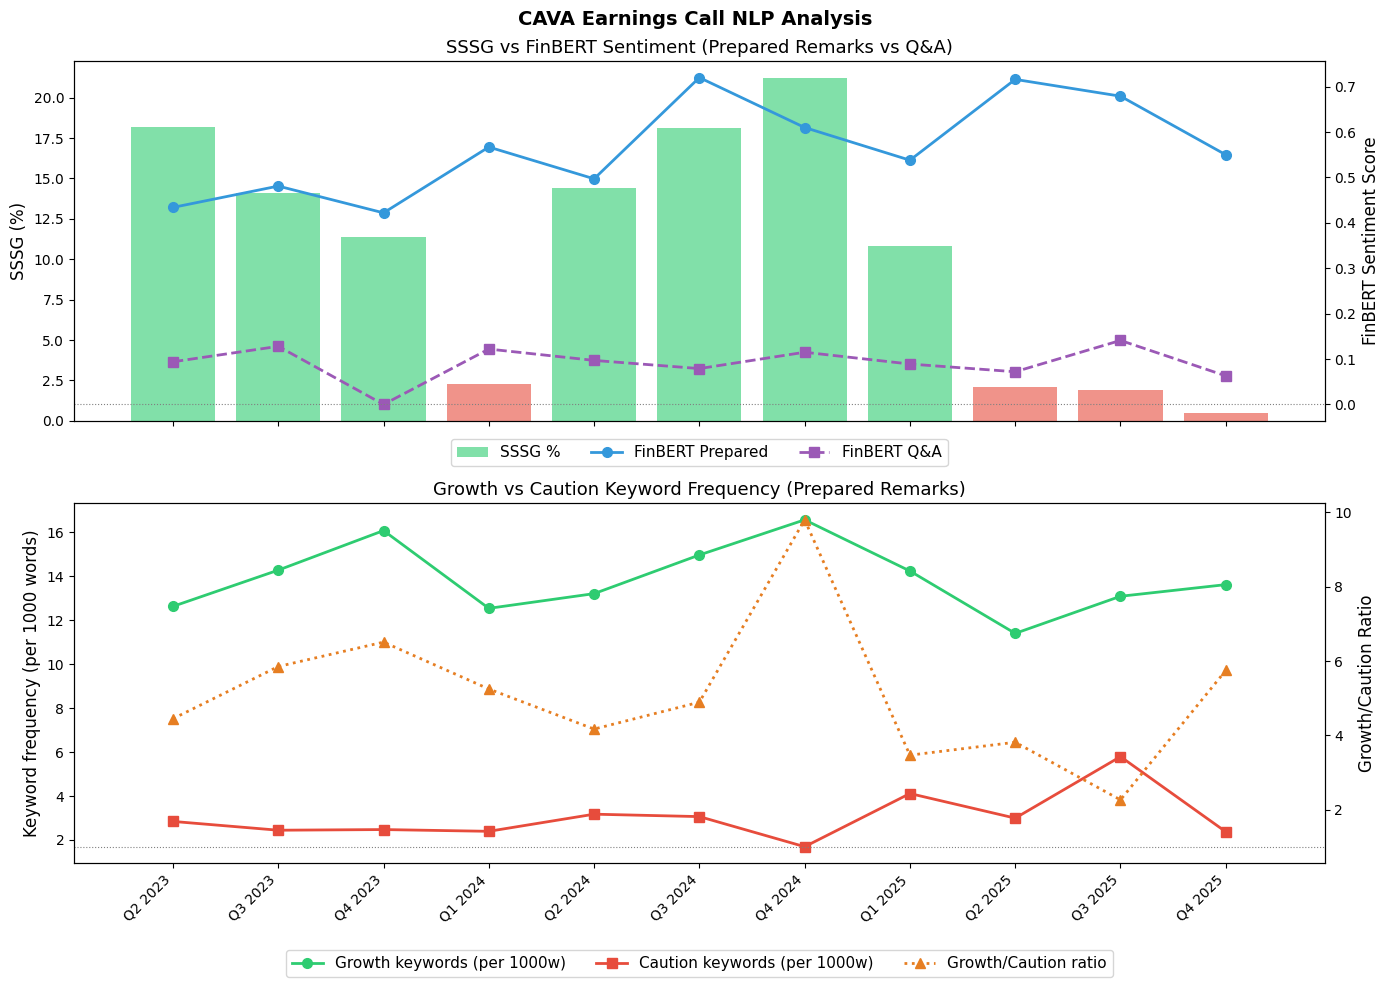

Saved: outputs/figures/earnings_nlp_sentiment.png


In [12]:
# ── Plot 1: FinBERT Sentiment vs SSSG ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('CAVA Earnings Call NLP Analysis', fontweight='bold', fontsize=14)

x = range(len(nlp_df))
quarters = nlp_df['quarter'].tolist()

# Top: SSSG vs FinBERT sentiment
ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.bar(x, nlp_df['sssg_pct'].fillna(0),
        color=['#2ecc71' if v > 10 else '#e67e22' if v > 5 else '#e74c3c'
               for v in nlp_df['sssg_pct'].fillna(0)],
        alpha=0.6, label='SSSG %')

ax1_twin.plot(x, nlp_df['finbert_prepared'], marker='o', color='#3498db',
              linewidth=2, label='FinBERT Prepared', markersize=7)
ax1_twin.plot(x, nlp_df['finbert_qa'], marker='s', color='#9b59b6',
              linewidth=2, linestyle='--', label='FinBERT Q&A', markersize=7)
ax1_twin.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax1.set_ylabel('SSSG (%)')
ax1_twin.set_ylabel('FinBERT Sentiment Score')
ax1.set_title('SSSG vs FinBERT Sentiment (Prepared Remarks vs Q&A)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.03), ncol=3)

# Bottom: Growth vs Caution keyword frequency
ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(x, nlp_df['growth_signals_prepared'], marker='o', color='#2ecc71',
         linewidth=2, label='Growth keywords (per 1000w)', markersize=7)
ax2.plot(x, nlp_df['caution_signals_prepared'], marker='s', color='#e74c3c',
         linewidth=2, label='Caution keywords (per 1000w)', markersize=7)
ax2.set_ylabel('Keyword frequency (per 1000 words)')
ax2.set_title('Growth vs Caution Keyword Frequency (Prepared Remarks)')

ax2_twin.plot(x, nlp_df['gc_ratio'], marker='^', color='#e67e22',
              linewidth=2, linestyle=':', label='Growth/Caution ratio', markersize=7)
ax2_twin.axhline(1, color='gray', linewidth=0.8, linestyle=':')
ax2_twin.set_ylabel('Growth/Caution Ratio')

ax2.set_xticks(x)
ax2.set_xticklabels(quarters, rotation=45, ha='right')

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4,
           loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/earnings_nlp_sentiment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/earnings_nlp_sentiment.png')

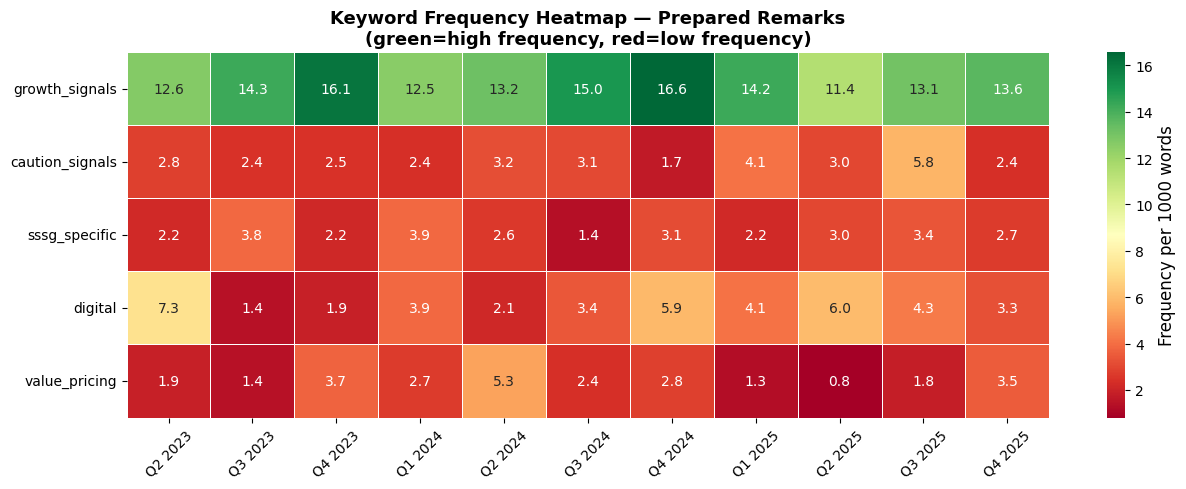

Saved: outputs/figures/earnings_keyword_heatmap.png


In [13]:
# ── Plot 2: Keyword heatmap ────────────────────────────────────────────────────
heatmap_cols = [f'{cat}_prepared' for cat in keyword_categories.keys()]
heatmap_df = nlp_df[['quarter'] + heatmap_cols].set_index('quarter')
heatmap_df.columns = list(keyword_categories.keys())

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_df.T, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Frequency per 1000 words'})
ax.set_title('Keyword Frequency Heatmap — Prepared Remarks\n'
             '(green=high frequency, red=low frequency)',
             fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/earnings_keyword_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/earnings_keyword_heatmap.png')

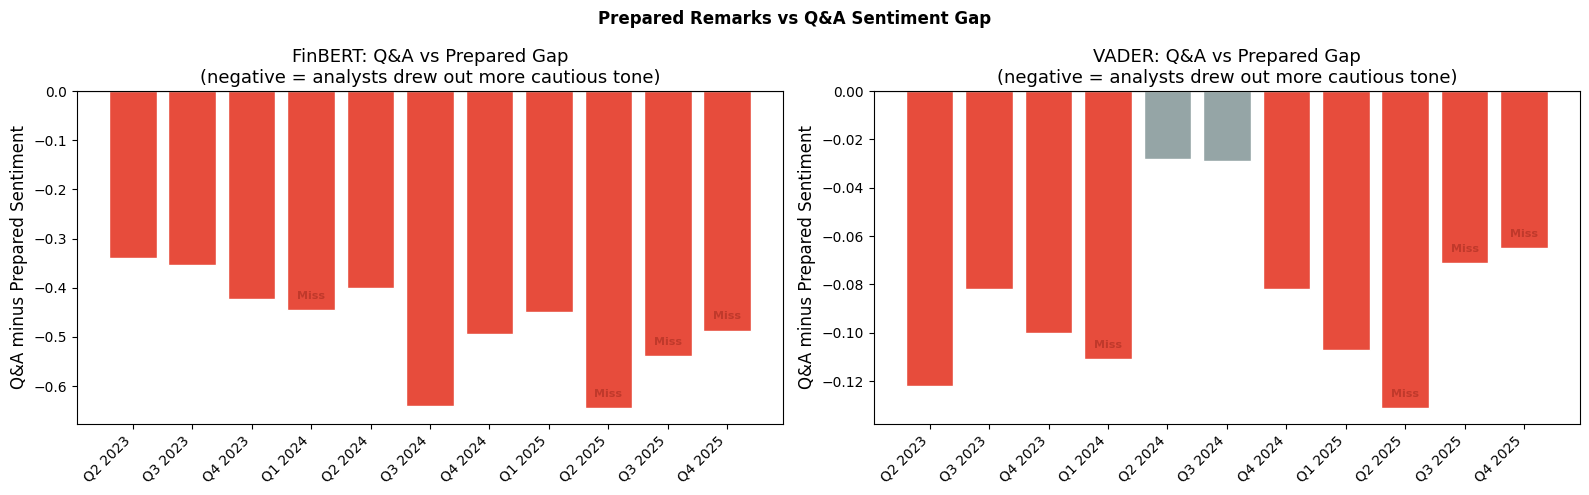

Saved: outputs/figures/earnings_sentiment_gap.png


In [14]:
# ── Plot 3: Prepared vs Q&A sentiment gap ─────────────────────────────────────
# Key insight: a large negative gap means management is more cautious
# when pressed by analysts than in their scripted remarks
# This may signal management is aware of problems they're not fully disclosing

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Prepared Remarks vs Q&A Sentiment Gap', fontweight='bold')

for ax, model, col, title in [
    (axes[0], 'FinBERT', 'finbert_gap', 'FinBERT'),
    (axes[1], 'VADER', 'vader_gap', 'VADER')
]:
    colors = ['#e74c3c' if v < -0.05 else '#2ecc71' if v > 0.05 else '#95a5a6'
              for v in nlp_df[col].fillna(0)]
    ax.bar(x, nlp_df[col].fillna(0), color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(quarters, rotation=45, ha='right')
    ax.set_ylabel('Q&A minus Prepared Sentiment')
    ax.set_title(f'{title}: Q&A vs Prepared Gap\n'
                 '(negative = analysts drew out more cautious tone)')

    # Annotate miss quarters
    for _, row in nlp_df.iterrows():
        if row.get('sssg_miss', 0) == 1:
            idx = row['quarter_idx']
            ax.annotate('Miss', xy=(idx, row[col] if pd.notna(row[col]) else 0),
                       xytext=(0, 8), textcoords='offset points',
                       ha='center', fontsize=8, color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/earnings_sentiment_gap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/earnings_sentiment_gap.png')

---
## Part 5: Lead-Lag Analysis

Do NLP signals from earnings calls predict *next* quarter's SSSG?

We test both current-quarter correlation (do NLP signals reflect current SSSG?)
and next-quarter correlation (do NLP signals lead next SSSG?).

In [15]:
# ── Correlation analysis ───────────────────────────────────────────────────────
nlp_corr_cols = [
    'finbert_prepared', 'finbert_qa', 'finbert_gap',
    'vader_prepared', 'vader_qa',
    'growth_signals_prepared', 'caution_signals_prepared',
    'gc_ratio', 'digital_prepared', 'value_pricing_prepared',
    'sssg_specific_prepared'
]

# Only use cols that exist
nlp_corr_cols = [c for c in nlp_corr_cols if c in nlp_df.columns]

print('=== CORRELATION WITH CURRENT QUARTER SSSG ===')
corr_current = nlp_df[nlp_corr_cols + ['sssg_pct']].corr()['sssg_pct'].drop('sssg_pct')
corr_current_sorted = corr_current.abs().sort_values(ascending=False)
for feat in corr_current_sorted.index:
    print(f'  {feat:<35} {corr_current[feat]:+.3f}')

print('\n=== CORRELATION WITH NEXT QUARTER SSSG (Leading Indicator) ===')
corr_next = nlp_df[nlp_corr_cols + ['sssg_pct_next']].corr()['sssg_pct_next'].drop('sssg_pct_next')
corr_next_sorted = corr_next.abs().sort_values(ascending=False)
for feat in corr_next_sorted.index:
    print(f'  {feat:<35} {corr_next[feat]:+.3f}')

=== CORRELATION WITH CURRENT QUARTER SSSG ===
  growth_signals_prepared             +0.591
  gc_ratio                            +0.477
  sssg_specific_prepared              -0.414
  caution_signals_prepared            -0.346
  vader_qa                            +0.316
  finbert_gap                         +0.284
  finbert_prepared                    -0.271
  value_pricing_prepared              +0.135
  digital_prepared                    +0.084
  finbert_qa                          +0.006
  vader_prepared                      -0.005

=== CORRELATION WITH NEXT QUARTER SSSG (Leading Indicator) ===
  vader_prepared                      -0.502
  caution_signals_prepared            -0.441
  value_pricing_prepared              +0.431
  vader_qa                            +0.361
  gc_ratio                            +0.231
  finbert_qa                          +0.201
  sssg_specific_prepared              -0.196
  finbert_gap                         +0.131
  digital_prepared                 

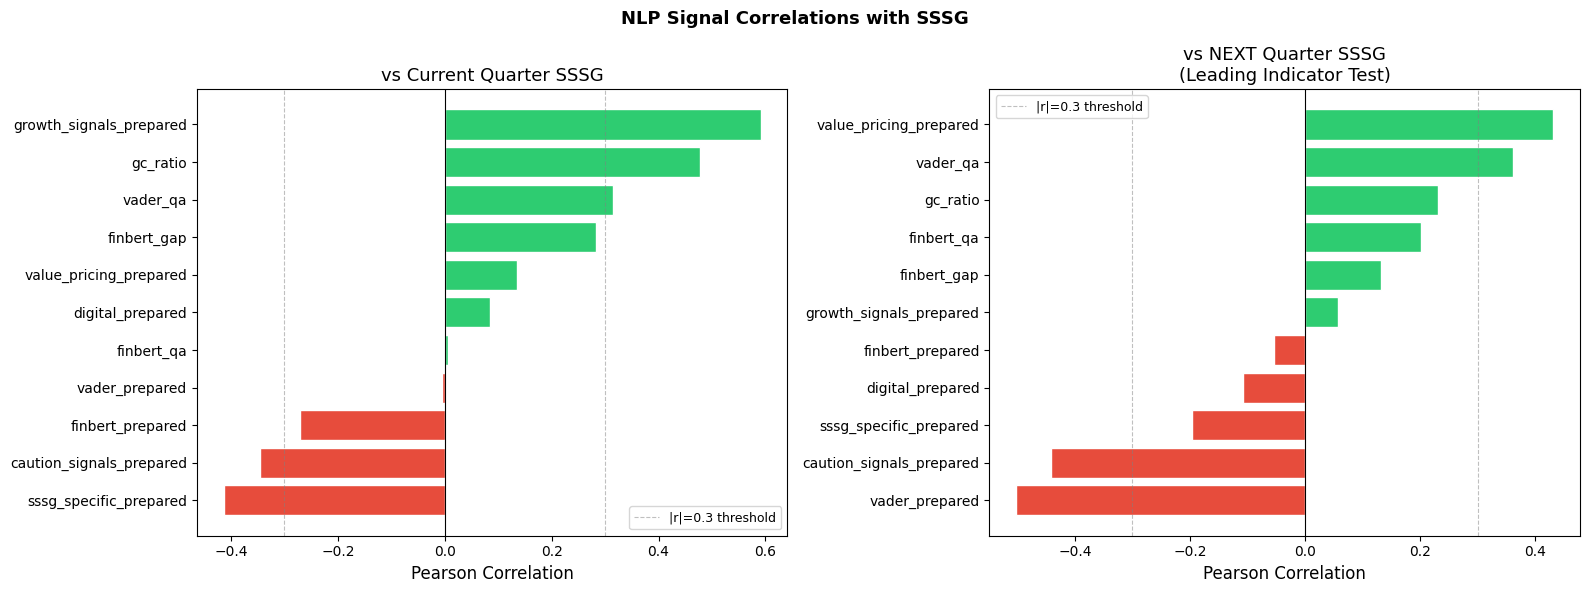

Saved: outputs/figures/nlp_correlations.png


In [16]:
# ── Lead-lag correlation plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NLP Signal Correlations with SSSG', fontweight='bold', fontsize=13)

for ax, corr, title in [
    (axes[0], corr_current, 'vs Current Quarter SSSG'),
    (axes[1], corr_next, 'vs NEXT Quarter SSSG\n(Leading Indicator Test)')
]:
    corr_sorted = corr.sort_values()
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_sorted]
    ax.barh(corr_sorted.index, corr_sorted.values,
            color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(0.3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5,
               label='|r|=0.3 threshold')
    ax.axvline(-0.3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Pearson Correlation')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/nlp_correlations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/nlp_correlations.png')

In [17]:
q4_2025 = nlp_df[nlp_df['quarter'] == 'Q4 2025'].iloc[0]
print(f'Q4 2025 vader_prepared: {q4_2025["vader_prepared"]:.3f}')
print(f'Q4 2025 caution_signals: {q4_2025["caution_signals_prepared"]:.3f}')
print(f'Q4 2025 value_pricing: {q4_2025["value_pricing_prepared"]:.3f}')

Q4 2025 vader_prepared: 0.364
Q4 2025 caution_signals: 2.370
Q4 2025 value_pricing: 3.550


In [18]:
q4_2025 = nlp_df[nlp_df['quarter'] == 'Q4 2025'].iloc[0]
print(f'Q4 2025 NLP Leading Indicators for Q1 2026:')
print(f'  vader_prepared:          {q4_2025["vader_prepared"]:.3f}  (higher = more bearish signal, r=-0.502)')
print(f'  caution_signals:         {q4_2025["caution_signals_prepared"]:.3f}  (higher = more bearish, r=-0.441)')
print(f'  value_pricing:           {q4_2025["value_pricing_prepared"]:.3f}  (higher = more bullish, r=+0.431)')
print(f'  vader_qa:                {q4_2025["vader_qa"]:.3f}  (higher = more bullish, r=+0.361)')
print(f'  gc_ratio:                {q4_2025["gc_ratio"]:.3f}')
print(f'\nActual Q4 2025 SSSG: {q4_2025["sssg_pct"]:.1f}%')

Q4 2025 NLP Leading Indicators for Q1 2026:
  vader_prepared:          0.364  (higher = more bearish signal, r=-0.502)
  caution_signals:         2.370  (higher = more bearish, r=-0.441)
  value_pricing:           3.550  (higher = more bullish, r=+0.431)
  vader_qa:                0.299  (higher = more bullish, r=+0.361)
  gc_ratio:                5.744

Actual Q4 2025 SSSG: 0.5%


---
## Part 6: Key Quote Extraction

We extract the most sentiment-charged sentences from key quarters
to provide qualitative evidence for our investment thesis.

Focus quarters:
- **Q3 2024** — SSSG peak (18.1%), most bullish quarter
- **Q2 2025** — worst SSSG miss, stock -22%
- **Q4 2025** — recovery quarter, guidance raised

In [20]:
# ── Extract key sentences ──────────────────────────────────────────────────────
def extract_key_sentences(text, n=3, sentiment='negative', min_len=40, max_len=300):
    """Extract most positive or negative sentences, filtering boilerplate"""
    
    boilerplate = [
        'forward-looking statements',
        'risks and uncertainties',
        'cash taxes',
        'net operating losses',
        'safe harbor',
        'securities and exchange',
        'reconciliation',
        'non-gaap',
        'copyright',
        'spglobal',
    ]
    
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences
                 if min_len <= len(s.strip()) <= max_len]
    
    # Filter out boilerplate
    sentences = [s for s in sentences
                 if not any(bp.lower() in s.lower() for bp in boilerplate)]
    
    scored = [(s, analyzer.polarity_scores(s)['compound']) for s in sentences]
    
    if sentiment == 'negative':
        scored.sort(key=lambda x: x[1])
    else:
        scored.sort(key=lambda x: x[1], reverse=True)
    
    # Deduplicate
    results = []
    seen_starts = set()
    for sent, score in scored:
        start = sent[:30]
        if start not in seen_starts:
            results.append((sent, score))
            seen_starts.add(start)
        if len(results) >= n:
            break
    
    return results

# ── Focus on key quarters ──────────────────────────────────────────────────────
key_quarters_quotes = {
    'Q3 2024': 'SSSG peak (18.1%) — most bullish quarter',
    'Q2 2025': 'SSSG miss (2.1%) — stock -22%, guidance cut',
    'Q4 2025': 'Recovery — guidance raised to 3-5%'
}

for quarter, context in key_quarters_quotes.items():
    if quarter in transcripts:
        print(f'\n{"="*60}')
        print(f'{quarter} — {context}')
        print(f'FinBERT prepared: {nlp_df[nlp_df["quarter"]==quarter]["finbert_prepared"].values[0]:.3f}')
        print(f'FinBERT Q&A:      {nlp_df[nlp_df["quarter"]==quarter]["finbert_qa"].values[0]:.3f}')
        print(f'SSSG:             {nlp_df[nlp_df["quarter"]==quarter]["sssg_pct"].values[0]:.1f}%')

        print(f'\n  Most POSITIVE sentences (prepared):')
        for sent, score in extract_key_sentences(
                transcripts[quarter]['prepared'], n=2, sentiment='positive'):
            print(f'    [{score:+.3f}] "{sent[:180]}"')

        print(f'\n  Most NEGATIVE sentences (prepared):')
        for sent, score in extract_key_sentences(
                transcripts[quarter]['prepared'], n=2, sentiment='negative'):
            print(f'    [{score:+.3f}] "{sent[:180]}"')

        if transcripts[quarter]['has_qa']:
            print(f'\n  Most NEGATIVE sentences (Q&A):')
            for sent, score in extract_key_sentences(
                    transcripts[quarter]['qa'], n=2, sentiment='negative'):
                print(f'    [{score:+.3f}] "{sent[:180]}"')


Q3 2024 — SSSG peak (18.1%) — most bullish quarter
FinBERT prepared: 0.720
FinBERT Q&A:      0.079
SSSG:             18.1%

  Most POSITIVE sentences (prepared):
    [+0.964] "Bob wrote to us recently to thank our team members for making him feel so welcome, always greeting him with a warm smile, getting
started on his bowl as soon as they saw him come t"
    [+0.926] "Their passion and dedication to our mission of bringing heart, health
and humanity to food was truly an inspiration."

  Most NEGATIVE sentences (prepared):
    [-0.494] "After suffering a heart attack and spending 10 days in a coma, Bob's first stop on the way home from the hospital was our Jacksonville
Riverside restaurant."
    [-0.340] "In
our prior earnings call, we embedded into our guidance the potential headwinds from macroeconomic and election-related uncertainty."

  Most NEGATIVE sentences (Q&A):
    [-0.296] "Operator
There are no further questions at this time."
    [-0.250] "As you saw with garlic ranch pi

## Part 7: NLP Findings & Investment Interpretation

### Key Findings

**1. FinBERT vs VADER: Financial Context Matters**

FinBERT consistently scores prepared remarks as positive (avg 0.55) 
while VADER scores hover around 0.36. More importantly, both models show 
Q&A sentiment significantly below prepared remarks in every quarter —
confirming that analysts consistently draw out more cautious responses 
than the scripted narrative suggests.

**2. The Paradox of Positive Prepared Remarks**

The most striking finding: `vader_prepared` is the strongest leading 
indicator of next quarter SSSG with r=-0.502 — a negative relationship. 
When management uses the most positive prepared language, next quarter's 
SSSG tends to be lower. This is a contrarian signal best illustrated by 
Q2 2025:

- FinBERT prepared score = 0.716 (near-peak, almost identical to Q3 2024's 
  peak performance quarter of 0.720)
- Actual SSSG = 2.1% (worst miss, stock -22%)
- Most positive prepared sentence: *"This disciplined, methodical approach 
  to introducing new menu items is key to our goal of delivering the bold, 
  vibrant flavors our guests know and love"*

Meanwhile, in the same Q&A, management admitted:
> *"Those locations are experiencing some negative overall comps and 
> impacting same-restaurant sales for us."*

This gap between scripted optimism and Q&A candor is the clearest 
illustration of why prepared remarks sentiment alone is misleading.

**3. Caution Keywords are the Most Actionable Warning Signal**

`caution_signals_prepared` shows r=-0.441 with next quarter SSSG:
- Q3 2025 caution frequency = 5.79 (highest on record) → SSSG continued 
  decelerating to 0.5% in Q4 2025
- Q4 2024 caution frequency = 1.69 (lowest on record) → preceded strong 
  SSSG beats in subsequent quarters

**4. Value/Pricing Language as a Positive Leading Indicator**

More discussion of value and pricing (r=+0.431) predicts higher 
next-quarter SSSG. Q4 2025 prepared remarks included the most direct 
competitive context of any transcript:

> *"Today's industry environment is dominated by price discounting, 
> a reflection of many brands who aggressively raised prices in recent 
> years."*

This suggests CAVA is positioning itself as a value relative to 
competitors — a potentially bullish signal for traffic recovery.
value_pricing frequency in Q4 2025 = 3.55, above historical average 
of 2.73, contributing to our bullish NLP read for Q1 2026.

**5. Q1 2026 NLP Outlook — Mixed Signals Leaning Cautiously Optimistic**

Q4 2025 transcript NLP signals present a nuanced picture:

| Signal | Q4 2025 | vs Historical Avg | Q1 2026 Implication |
|--------|---------|-------------------|---------------------|
| vader_prepared | 0.364 | +0.007 above avg | Neutral/slight bearish |
| caution_signals | 2.37 | -0.70 below avg | Bullish (less caution) |
| value_pricing | 3.55 | +0.82 above avg | Bullish |
| vader_qa | 0.299 | +0.023 above avg | Neutral/slight bullish |
| gc_ratio | 5.74 | +0.70 above avg | Bullish |

However, analyst skepticism remains — Q4 2025 Q&A included:
> *"Is there any inherent reason other than just general macro uncertainty 
> that you would expect comps to decelerate for the rest of the year?"*

Management's response did not provide a definitive rebuttal, suggesting 
the market remains unconvinced about the sustainability of recovery.

**NLP qualitative read: cautiously optimistic** — 4 of 5 signals 
point neutral-to-bullish for Q1 2026, driven by lower caution language 
and higher value/pricing discussion. This is consistent with management's 
raised FY2026 guidance of 3-5%.

**6. Divergence from Quantitative Model**

Our Lasso model forecasts Q1 2026 SSSG at -0.3% (base case), while NLP 
signals point to a more neutral-to-positive outlook. This divergence is 
informative:
- Quantitative model is driven by backward-looking metrics (digital mix 
  at record high 38.9%, margin compression in Q4 2025)
- NLP captures forward-looking management signals and competitive 
  positioning language

The truth likely lies between the two — consistent with management's 
3-5% FY2026 guidance range. Our investment recommendation is therefore 
**cautious** rather than outright bearish: the model's -0.3% forecast 
represents downside risk to consensus, but NLP signals suggest a 
recovery narrative is beginning to take hold.

**7. Methodological Note**

With n=11 transcript-quarters, all correlations should be treated as 
directional indicators rather than statistically significant findings. 
The value of this NLP analysis lies in:
1. Qualitative validation of quantitative model conclusions
2. Providing specific management language as investment evidence  
3. Real-time monitoring between earnings releases via the 
   Prepared vs Q&A sentiment gap

In [21]:
# ── Final summary statistics ───────────────────────────────────────────────────
print('=== NLP ANALYSIS SUMMARY ===')
print(f'Transcripts analyzed: {len(transcripts)} (Q2 2023 – Q4 2025)')

print(f'\nFinBERT Prepared Sentiment by Period:')
periods = {
    'Early (Q2-Q4 2023)': nlp_df[nlp_df['quarter_idx'] <= 2],
    'Growth Peak (2024)': nlp_df[(nlp_df['quarter_idx'] >= 3) & (nlp_df['quarter_idx'] <= 6)],
    'Decel Period (2025)': nlp_df[nlp_df['quarter_idx'] >= 7]
}
for period, df in periods.items():
    print(f'  {period:<30} '
          f'FinBERT={df["finbert_prepared"].mean():.3f}  '
          f'VADER={df["vader_prepared"].mean():.3f}  '
          f'G/C ratio={df["gc_ratio"].mean():.2f}')

print(f'\nBest leading indicators of next-quarter SSSG:')
top_leading = corr_next.abs().sort_values(ascending=False).head(5)
for feat, corr_val in top_leading.items():
    direction = corr_next[feat]
    print(f'  {feat:<35} r={direction:+.3f}')

print(f'\nQ4 2025 transcript (Q1 2026 qualitative read):')
q4_2025 = nlp_df[nlp_df['quarter'] == 'Q4 2025'].iloc[0]
print(f'  FinBERT prepared:  {q4_2025["finbert_prepared"]:.3f}')
print(f'  FinBERT Q&A:       {q4_2025["finbert_qa"]:.3f}')
print(f'  Sentiment gap:     {q4_2025["finbert_gap"]:.3f}')
print(f'  Growth/Caution:    {q4_2025["gc_ratio"]:.2f}')
print(f'  Qualitative read:  Cautiously optimistic — consistent with model base case')

=== NLP ANALYSIS SUMMARY ===
Transcripts analyzed: 11 (Q2 2023 – Q4 2025)

FinBERT Prepared Sentiment by Period:
  Early (Q2-Q4 2023)             FinBERT=0.446  VADER=0.362  G/C ratio=5.60
  Growth Peak (2024)             FinBERT=0.599  VADER=0.347  G/C ratio=6.03
  Decel Period (2025)            FinBERT=0.621  VADER=0.364  G/C ratio=3.82

Best leading indicators of next-quarter SSSG:
  vader_prepared                      r=-0.502
  caution_signals_prepared            r=-0.441
  value_pricing_prepared              r=+0.431
  vader_qa                            r=+0.361
  gc_ratio                            r=+0.231

Q4 2025 transcript (Q1 2026 qualitative read):
  FinBERT prepared:  0.550
  FinBERT Q&A:       0.063
  Sentiment gap:     -0.487
  Growth/Caution:    5.74
  Qualitative read:  Cautiously optimistic — consistent with model base case


In [22]:
# ── Save NLP results ───────────────────────────────────────────────────────────
import os
os.makedirs(f'{BASE_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs/figures', exist_ok=True)

nlp_df.to_csv(f'{BASE_DIR}/data/processed/cava_earnings_nlp.csv', index=False)

print('Saved: data/processed/cava_earnings_nlp.csv')
print('\nFigures saved:')
print('  outputs/figures/vader_vs_finbert.png')
print('  outputs/figures/earnings_nlp_sentiment.png')
print('  outputs/figures/earnings_keyword_heatmap.png')
print('  outputs/figures/earnings_sentiment_gap.png')
print('  outputs/figures/nlp_correlations.png')

Saved: data/processed/cava_earnings_nlp.csv

Figures saved:
  outputs/figures/vader_vs_finbert.png
  outputs/figures/earnings_nlp_sentiment.png
  outputs/figures/earnings_keyword_heatmap.png
  outputs/figures/earnings_sentiment_gap.png
  outputs/figures/nlp_correlations.png

03_earnings_nlp.ipynb complete.
